<a href="https://colab.research.google.com/github/Lingasamy-DS/Eco_cover_type-/blob/main/2_Data_Preprocessing_and_EDA_21_06_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**REading the stored dataset with outlier controlled**

In [ ]:
data_1 = pd.read_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/data_new.csv")
data.head(20)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,Aspen,1,29
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,Aspen,1,29
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,Lodgepole Pine,1,12
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,Lodgepole Pine,1,30
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,Aspen,1,29
5,2579.0,132.0,6.0,300.0,-15.0,67.0,230.0,237.0,140.0,6031.0,Lodgepole Pine,1,29
6,2606.0,45.0,7.0,270.0,5.0,633.0,222.0,225.0,138.0,6256.0,Aspen,1,29
7,2605.0,49.0,4.0,234.0,7.0,573.0,222.0,230.0,144.0,6228.0,Aspen,1,29
8,2617.0,45.0,9.0,240.0,56.0,666.0,223.0,221.0,133.0,6244.0,Aspen,1,29
9,2612.0,59.0,10.0,247.0,11.0,636.0,228.0,219.0,124.0,6230.0,Aspen,1,29


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/data.csv")
data.head(20)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,Aspen,1,29
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,Aspen,1,29
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,Lodgepole Pine,1,12
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,Lodgepole Pine,1,30
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,Aspen,1,29
5,2579.0,132.0,6.0,300.0,-15.0,67.0,230.0,237.0,140.0,6031.0,Lodgepole Pine,1,29
6,2606.0,45.0,7.0,270.0,5.0,633.0,222.0,225.0,138.0,6256.0,Aspen,1,29
7,2605.0,49.0,4.0,234.0,7.0,573.0,222.0,230.0,144.0,6228.0,Aspen,1,29
8,2617.0,45.0,9.0,240.0,56.0,666.0,223.0,221.0,133.0,6244.0,Aspen,1,29
9,2612.0,59.0,10.0,247.0,11.0,636.0,228.0,219.0,124.0,6230.0,Aspen,1,29


**Creating New Features**

In [ ]:
#1.Euclidean Distance To Hydrology feature
data['Euclidean_Distance_To_Hydrology'] = np.sqrt(data['Horizontal_Distance_To_Hydrology']**2 + data['Vertical_Distance_To_Hydrology']**2)
#2.Hiullshade_Avg Feature
data['Hillshade_Avg'] = (data['Hillshade_9am'] + data['Hillshade_Noon'] + data['Hillshade_3pm']) / 3

#3.Creating the catagorical feature according to the aspect directions
def categorize_aspect(aspect):
    if (aspect >= 0 and aspect < 45) or (aspect >= 315 and aspect <= 360):
        return 'North'
    elif aspect >= 45 and aspect < 135:
        return 'East'
    elif aspect >= 135 and aspect < 225:
        return 'South'
    elif aspect >= 225 and aspect < 315:
        return 'West'
    else:
        return 'Unknown'

data['Aspect_Category'] = data['Aspect'].apply(categorize_aspect)

#4. Hydro_fire_interaction feature
data["Hydro_fire_interaction"] = abs(data["Horizontal_Distance_To_Hydrology"] -data["Horizontal_Distance_To_Fire_Points"])
#5.Slope _elevation_interaction feature
data["Slope_elevation_interaction"] = (data["Slope"] *data["Elevation"])

In [ ]:
data["Cover_Type"][data["Slope_elevation_interaction"]>25000].value_counts()

,count
Cover_Type,
Lodgepole Pine,66006
Spruce/Fir,21774
Aspen,2283
Ponderosa Pine,1882
Douglas-fir,1867
Krummholz,1787
Cottonwood/Willow,1619


In [ ]:
data["Cover_Type"].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


In [ ]:
data_corr =data.select_dtypes(exclude = ["object"]).corr().round(2)
data_corr

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Euclidean_Distance_To_Hydrology,Hillshade_Avg,Hydro_fire_interaction,Slope_elevation_interaction
Elevation,1.00,0.02,-0.13,0.36,0.15,0.69,-0.01,0.13,0.09,0.19,-0.33,0.50,0.36,0.14,0.15,0.03
Aspect,0.02,1.00,0.07,0.01,0.09,0.11,-0.56,0.34,0.63,-0.05,0.06,0.07,0.01,0.40,-0.05,0.07
Slope,-0.13,0.07,1.00,-0.11,0.22,-0.06,-0.15,-0.55,-0.26,-0.20,0.25,0.16,-0.10,-0.58,-0.19,0.99
Horizontal_Distance_To_Hydrology,0.36,0.01,-0.11,1.00,0.53,0.26,-0.06,0.11,0.12,0.10,-0.06,0.06,1.00,0.12,-0.01,-0.06
Vertical_Distance_To_Hydrology,0.15,0.09,0.22,0.53,1.00,0.15,-0.14,-0.06,0.06,-0.02,0.12,0.06,0.55,-0.05,-0.08,0.24
Horizontal_Distance_To_Roadways,0.69,0.11,-0.06,0.26,0.15,1.00,-0.08,0.22,0.18,0.28,-0.33,0.34,0.26,0.22,0.25,0.04
Hillshade_9am,-0.01,-0.56,-0.15,-0.06,-0.14,-0.08,1.00,-0.02,-0.81,0.03,-0.08,-0.07,-0.06,-0.16,0.03,-0.15
Hillshade_Noon,0.13,0.34,-0.55,0.11,-0.06,0.22,-0.02,1.00,0.57,0.08,-0.11,-0.04,0.10,0.98,0.07,-0.53
Hillshade_3pm,0.09,0.63,-0.26,0.12,0.06,0.18,-0.81,0.57,1.00,0.04,-0.01,0.02,0.11,0.70,0.03,-0.25
Horizontal_Distance_To_Fire_Points,0.19,-0.05,-0.20,0.10,-0.02,0.28,0.03,0.08,0.04,1.00,-0.30,0.02,0.09,0.09,0.99,-0.17


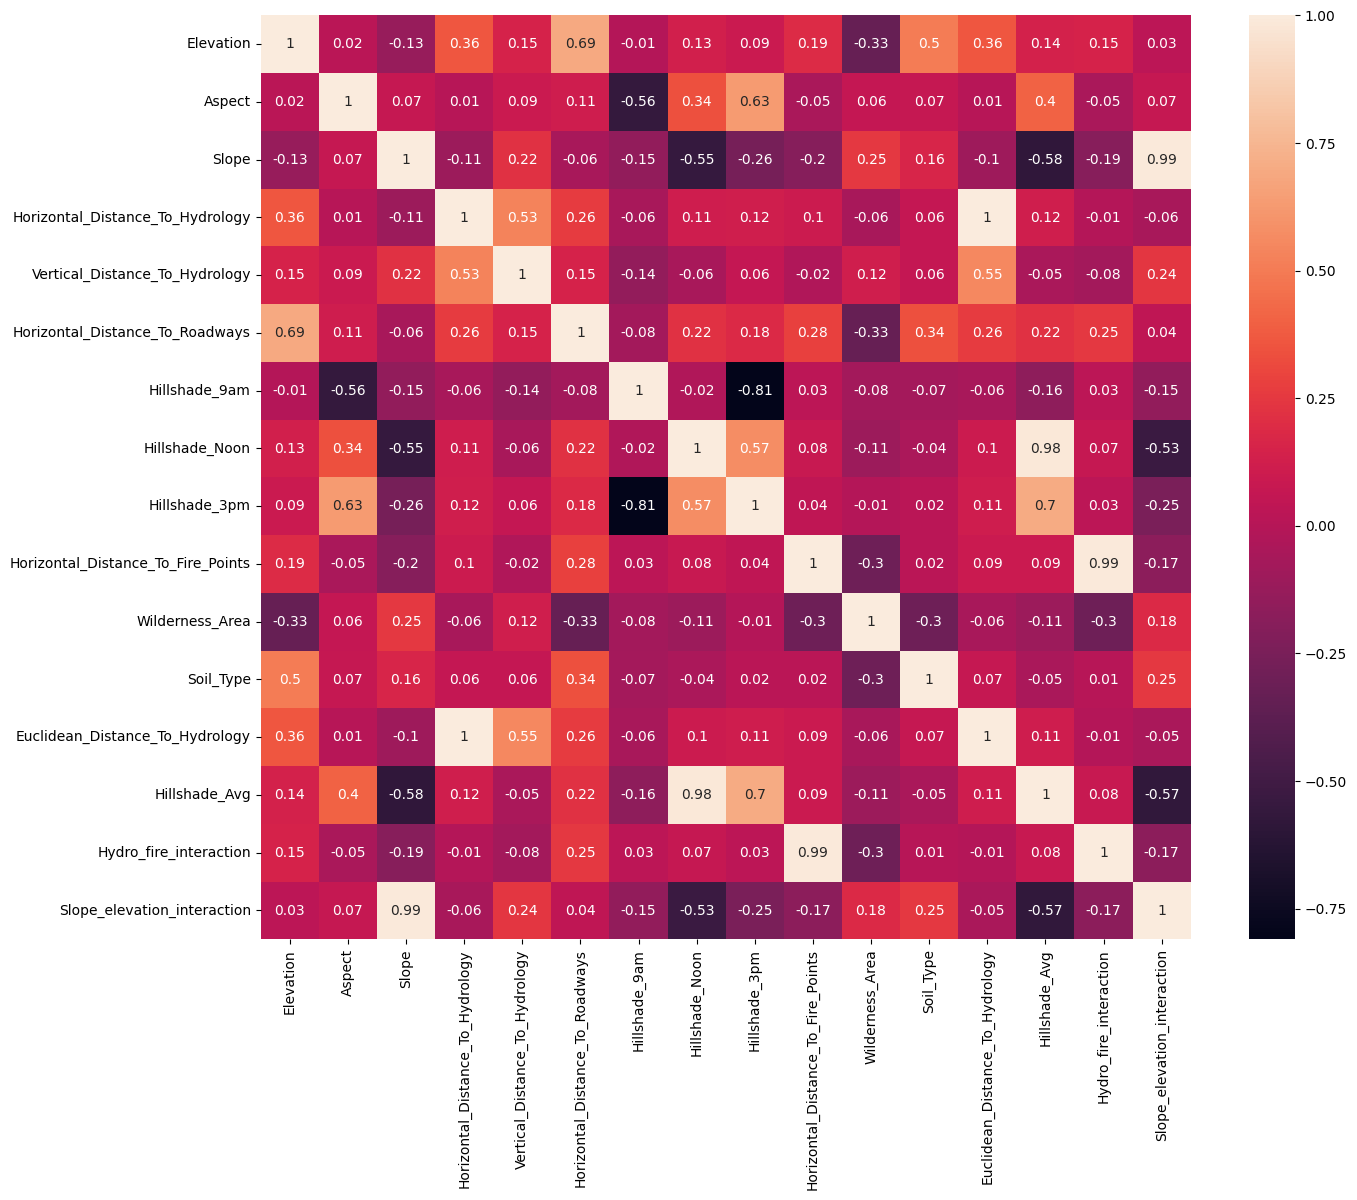

In [ ]:
plt.figure(figsize=(15,12))
sns.heatmap(data= data_corr, annot= True)
plt.show()

In [ ]:
data.select_dtypes(exclude = ["object"]).columns


Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slope_elevation_interaction'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split


X = data.drop("Cover_Type", axis=1)
y = data["Cover_Type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state =42 )

In [ ]:
X_train.to_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/X_traindata.csv", index =False)
y_train.to_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/y_train.csv", index =False)
X_test.to_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/X_test.csv", index =False)
y_test.to_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/y_test.csv", index =False)


In [ ]:
X_train = pd.read_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/X_traindata.csv")
y_train = pd.read_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/y_train.csv")
X_test = pd.read_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/X_test.csv")
y_test = pd.read_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/y_test.csv")

**Checcking the skewness in the training data**

In [ ]:
X_train.select_dtypes(exclude=["object"]).columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slope_elevation_interaction'],
      dtype='object')

In [ ]:
numerical_col = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slope_elevation_interaction']
skewness = X_train[numerical_col].skew()
skewness


,0
Elevation,-0.339490
Aspect,0.688103
Slope,0.622059
Horizontal_Distance_To_Hydrology,0.794181
Vertical_Distance_To_Hydrology,0.862814
Horizontal_Distance_To_Roadways,-0.060584
Hillshade_9am,-0.739235
Hillshade_Noon,-0.502747
Hillshade_3pm,-0.000864
Horizontal_Distance_To_Fire_Points,0.366899


In [ ]:
train_data = pd.concat([X_train, y_train], axis=1)
train_data.shape

(116712, 18)

In [ ]:
test_data = pd.concat([X_test, y_test], axis=1)
test_data.shape

(29178, 18)

In [ ]:
train_data.to_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/train_data.csv", index =False)
test_data.to_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/test_data.csv", index =False)

**YoeJhonson Transformer to handle the skewness**

In [ ]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 14.1 MB/s eta 0:00:00


In [ ]:
from feature_engine.transformation import YeoJohnsonTransformer
skew_data = skewness[abs(skewness)>0.4]
yeo_transformer = YeoJohnsonTransformer(variables = skew_data.index.tolist())
data_transformed = yeo_transformer.fit_transform(train_data[skew_data.index.tolist()])

for col in skew_data.index:
  train_data[col] = data_transformed[col]

skew_yj = train_data[numerical_col].skew()
skew_yj

,0
Elevation,-0.339490
Aspect,-0.099626
Slope,-0.020458
Horizontal_Distance_To_Hydrology,-0.168662
Vertical_Distance_To_Hydrology,0.088099
Horizontal_Distance_To_Roadways,-0.060584
Hillshade_9am,-0.097879
Hillshade_Noon,-0.040304
Hillshade_3pm,-0.000864
Horizontal_Distance_To_Fire_Points,0.366899


In [ ]:
with open("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/yj.pkl", "wb") as file:
  pickle.dump(yeo_transformer, file)

In [ ]:
train_data.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Euclidean_Distance_To_Hydrology,Hillshade_Avg,Hydro_fire_interaction,Slope_elevation_interaction
count,116712.000000,116712.000000,116712.000000,116712.000000,116712.000000,116712.000000,1.167120e+05,1.167120e+05,116712.000000,116712.000000,116712.000000,116712.000000,116712.000000,1.167120e+05,116712.000000,116712.000000
mean,2877.779616,13.083136,4.664516,22.363685,21.711659,3312.009699,3.231074e+09,2.103656e+08,140.015637,3045.009853,1.187761,23.372695,22.995542,1.074707e+12,125.485259,603.360939
std,198.225321,5.302544,1.544967,10.032040,23.623171,1687.941415,1.108705e+09,5.044953e+07,30.308863,1762.459334,0.658259,8.215379,10.318357,3.062998e+11,48.846928,180.363908
min,2361.500000,0.000000,0.000000,0.000000,-87.344586,0.000000,1.037246e+09,1.002923e+08,64.000000,0.000000,1.000000,1.000000,0.000000,1.670537e+11,0.000000,0.000000
25%,2747.000000,9.291539,3.487810,15.148639,5.921597,1842.000000,2.450665e+09,1.758978e+08,121.000000,1608.000000,1.000000,12.000000,15.615274,8.684557e+11,89.537985,479.781327
50%,2909.000000,12.802859,4.651517,22.731328,17.360587,3421.000000,3.311874e+09,2.085165e+08,140.000000,2713.500000,1.000000,29.000000,23.401637,1.073190e+12,124.517376,604.377956
75%,3004.000000,17.422411,5.619982,29.546018,35.296263,4674.000000,4.003746e+09,2.453777e+08,159.000000,4477.000000,1.000000,29.000000,30.415727,1.280418e+12,167.081029,725.643452
max,3389.500000,21.635137,7.916410,42.418918,73.586058,7117.000000,5.914693e+09,3.235031e+08,216.000000,7172.000000,4.000000,40.000000,43.717181,1.747965e+12,223.001819,1092.763325


**Scaling the training data and saving as a pickle file**

In [ ]:
from sklearn.preprocessing import StandardScaler
import pickle
sd = StandardScaler()
train_data[numerical_col]=sd.fit_transform(train_data[numerical_col])
test_data[numerical_col]=sd.transform(test_data[numerical_col])

with open("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/sd.pkl", "wb") as file:
  pickle.dump(sd, file)

In [ ]:
train_data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Euclidean_Distance_To_Hydrology,Hillshade_Avg,Aspect_Category,Hydro_fire_interaction,Slope_elevation_interaction,Cover_Type
0,0.540904,-1.131123,-0.558045,-0.181155,-0.266110,0.013028,-0.152039,-0.305003,-0.000516,1.823023,1,29,-0.194474,-0.230318,North,1.604242,-0.505020,Lodgepole Pine
1,-0.266262,0.483868,-0.365606,-0.259596,-0.151381,-0.365541,0.373528,1.343565,0.296428,-0.306397,1,12,-0.268625,1.235793,South,-0.092581,-0.402763,Lodgepole Pine
2,0.803233,1.242190,-0.183187,2.030259,2.182841,1.585957,-1.279006,1.011305,1.550192,0.336458,1,29,2.039644,1.235793,West,0.201720,-0.092395,Lodgepole Pine
3,0.359292,-0.601573,-1.474177,-0.334966,-0.179827,0.677153,0.131244,0.391227,0.164453,1.454219,1,29,-0.343459,0.447298,East,1.364514,-1.437164,Lodgepole Pine
4,1.408607,-1.009703,0.761265,1.080118,2.182841,0.811045,-0.152039,-1.357178,-0.726379,-0.502147,1,29,1.113454,-1.302144,North,-0.490786,0.989448,Spruce/Fir


**Balancing the test data**

In [ ]:
from imblearn.over_sampling import SMOTE, SMOTENC
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Define categorical columns to be used for SMOTENC
categorical_cols = ['Aspect_Category', 'Wilderness_Area', "Soil_Type"]

X = train_data.drop("Cover_Type", axis =1)

# Define target (y)
y = train_data["Cover_Type"]

# SMOTE needs categorical columns as indices for non-continuous features
categorical_indices = [X.columns.get_loc(col) for col in categorical_cols]

# Apply SMOTE
smote = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Convert to DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['Cover_Type'] = y_resampled

# Verify the new class distribution
display(df_resampled['Cover_Type'].value_counts())

,count
Cover_Type,
Lodgepole Pine,82362
Spruce/Fir,82362
Cottonwood/Willow,82362
Ponderosa Pine,82362
Douglas-fir,82362
Aspen,82362
Krummholz,82362


In [ ]:
df_resampled.to_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/df_resampled.csv", index =False)

In [ ]:
df_resampled.shape


(576534, 18)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_col= ['Soil_Type', 'Wilderness_Area','Aspect_Category']

# Initialize OneHotEncoder
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

encoded_data = ohe.fit_transform(df_resampled[cat_col])
encoded_data=encoded_data.astype(int)

encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(cat_col))


datas_encoded = pd.concat([df_resampled.drop(columns=cat_col), encoded_df], axis=1)

datas_encoded.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Aspect_Category_North,Aspect_Category_South,Aspect_Category_West
0,0.540904,-1.131123,-0.558045,-0.181155,-0.266110,0.013028,-0.152039,-0.305003,-0.000516,1.823023,...,0,0,0,0,0,0,0,1,0,0
1,-0.266262,0.483868,-0.365606,-0.259596,-0.151381,-0.365541,0.373528,1.343565,0.296428,-0.306397,...,0,0,0,0,0,0,0,0,1,0
2,0.803233,1.242190,-0.183187,2.030259,2.182841,1.585957,-1.279006,1.011305,1.550192,0.336458,...,0,0,0,0,0,0,0,0,0,1
3,0.359292,-0.601573,-1.474177,-0.334966,-0.179827,0.677153,0.131244,0.391227,0.164453,1.454219,...,0,0,0,0,0,0,0,0,0,0
4,1.408607,-1.009703,0.761265,1.080118,2.182841,0.811045,-0.152039,-1.357178,-0.726379,-0.502147,...,0,0,0,0,0,0,0,1,0,0


**Applying the One Hot encoding to the test_data files**

In [ ]:
datas_encoded.to_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/data_encoded.csv",index=False)

In [ ]:
datas_encoded = pd.read_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/data_encoded.csv")
datas_encoded.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Aspect_Category_North,Aspect_Category_South,Aspect_Category_West
0,0.540904,-1.131123,-0.558045,-0.181155,-0.266110,0.013028,-0.152039,-0.305003,-0.000516,1.823023,...,0,0,0,0,0,0,0,1,0,0
1,-0.266262,0.483868,-0.365606,-0.259596,-0.151381,-0.365541,0.373528,1.343565,0.296428,-0.306397,...,0,0,0,0,0,0,0,0,1,0
2,0.803233,1.242190,-0.183187,2.030259,2.182841,1.585957,-1.279006,1.011305,1.550192,0.336458,...,0,0,0,0,0,0,0,0,0,1
3,0.359292,-0.601573,-1.474177,-0.334966,-0.179827,0.677153,0.131244,0.391227,0.164453,1.454219,...,0,0,0,0,0,0,0,0,0,0
4,1.408607,-1.009703,0.761265,1.080118,2.182841,0.811045,-0.152039,-1.357178,-0.726379,-0.502147,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
with open("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/ohe.pkl", "wb") as file:
  pickle.dump(ohe, file)

**Label Encoding of the target Features**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
datas_encoded["Cover_Type"] = le.fit_transform(datas_encoded["Cover_Type"])
datas_encoded["Cover_Type"].value_counts()

with open("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/label_encoder.pkl", "wb") as file:
  pickle.dump(le, file)

In [ ]:
datas_encoded["Cover_Type"].head()

,Cover_Type
0,4
1,4
2,4
3,4
4,6


In [ ]:
test_data = pd.read_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/test_data.csv")
test_data.shape

(29178, 18)

In [ ]:
test_data.select_dtypes(exclude=["object"]).columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slope_elevation_interaction'],
      dtype='object')

In [ ]:
def categorize_aspect(aspect):
    if (aspect >= 0 and aspect < 45) or (aspect >= 315 and aspect <= 360):
        return 'North'
    elif aspect >= 45 and aspect < 135:
        return 'East'
    elif aspect >= 135 and aspect < 225:
        return 'South'
    elif aspect >= 225 and aspect < 315:
        return 'West'
    else:
        return 'Unknown'

# Create 'Aspect_Category' in test_data
test_data['Aspect_Category'] = test_data['Aspect'].apply(categorize_aspect)

cat_cols= ['Soil_Type', 'Wilderness_Area','Aspect_Category']

# Correct num_cols to match the numerical_col used for fitting the StandardScaler
num_cols_for_scaling = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slope_elevation_interaction']

skew_data = skewness[abs(skewness)>0.4]

lab_col = ["Cover_Type"]

with open("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/sd.pkl", "rb") as file:
  loaded_scale = pickle.load(file)

with open("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/ohe.pkl", "rb") as file:
  loaded_ohe_encoded = pickle.load(file)

with open("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/label_encoder.pkl", "rb") as file:
  loaded_label_encoder = pickle.load(file)

with open("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/yj.pkl", "rb") as file:
  loaded_yj = pickle.load(file)

# Transform numerical features
test_scaled_num = loaded_scale.transform(test_data[num_cols_for_scaling])
test_scaled_num_df = pd.DataFrame(test_scaled_num, columns=num_cols_for_scaling, index=test_data.index)

# Transform categorical features
test_ohe_cat = loaded_ohe_encoded.transform(test_data[cat_cols])
test_ohe_cat_df = pd.DataFrame(test_ohe_cat, columns=loaded_ohe_encoded.get_feature_names_out(cat_cols), index=test_data.index)

# Encode Cover_Type
test_encoded_cover_type = loaded_label_encoder.transform(test_data["Cover_Type"])

#YoeJhonson Transformer
test_yj_transformed = loaded_yj.transform(test_encoded[skew_data.index.tolist()])
for col in skew_data.index:
  test_data[col] = test_yj_transformed[col]

# Combine all transformed features
test_encoded = pd.concat([test_scaled_num_df, test_ohe_cat_df], axis=1)
test_encoded["Cover_Type"] = test_encoded_cover_type
test_encoded.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_38,Soil_Type_39,Soil_Type_40,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Aspect_Category_North,Aspect_Category_South,Aspect_Category_West,Cover_Type
0,0.389560,1.081026,1.166005,1.126385,0.780451,1.360237,-1.917948,1.602846,2.342043,1.308966,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4
1,-0.695069,-0.990634,-0.558045,-0.977229,-0.874924,-0.909994,-0.041272,-0.305003,-0.099497,-1.210251,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4
2,-0.119963,-0.068189,0.761265,-0.627116,0.071429,0.381526,1.652684,-0.434264,-1.353261,0.009640,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4
3,-2.604520,-0.119716,2.108098,0.350553,2.182841,-1.656468,2.330618,-2.181860,-2.508044,-0.714351,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1
4,-0.079605,0.151782,-0.762272,1.054921,0.831072,-0.356062,0.764426,0.694005,-0.132491,-0.179869,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4


In [ ]:
test_encoded.shape

(29178, 59)

In [ ]:
test_encoded.to_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/test_encoded.csv", index= False)

**Feature Importance Checking**

In [ ]:
from sklearn.ensemble import RandomForestClassifier


# Define X (features) by dropping the original 'Cover_Type' and its one-hot encoded versions
X = datas_encoded.drop(columns=["Cover_Type"])

# Define y (target) using the original 'Cover_Type' column
y = datas_encoded["Cover_Type"]

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top features
feature_importance_df

,Feature,Importance
0,Elevation,0.200330
5,Horizontal_Distance_To_Roadways,0.100258
9,Horizontal_Distance_To_Fire_Points,0.067203
12,Hydro_fire_interaction,0.062775
3,Horizontal_Distance_To_Hydrology,0.046198
54,Wilderness_Area_4,0.044540
10,Euclidean_Distance_To_Hydrology,0.041126
53,Wilderness_Area_3,0.036426
4,Vertical_Distance_To_Hydrology,0.033528
6,Hillshade_9am,0.030390


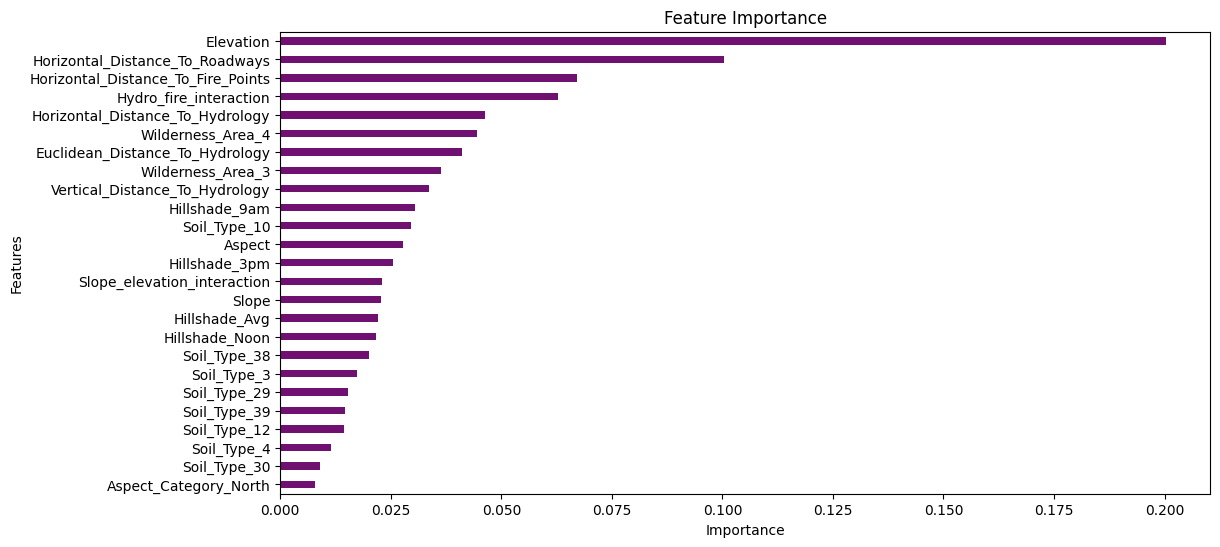

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.barplot(data=feature_importance_df.head(25), x="Importance", y="Feature", color="purple", width =0.4 )
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
data_col = feature_importance_df["Feature"].head(20).tolist()
data_col

['Elevation',
 'Horizontal_Distance_To_Roadways',
 'Horizontal_Distance_To_Fire_Points',
 'Hydro_fire_interaction',
 'Horizontal_Distance_To_Hydrology',
 'Wilderness_Area_4',
 'Euclidean_Distance_To_Hydrology',
 'Wilderness_Area_3',
 'Vertical_Distance_To_Hydrology',
 'Hillshade_9am',
 'Soil_Type_10',
 'Aspect',
 'Hillshade_3pm',
 'Slope_elevation_interaction',
 'Slope',
 'Hillshade_Avg',
 'Hillshade_Noon',
 'Soil_Type_38',
 'Soil_Type_3',
 'Soil_Type_29']

In [ ]:
feature_importance_df.to_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/feature_importance.csv", index =False)

**Exploratory Data Analysis**

In [ ]:
#Outlier handled dataset
data = pd.read_csv("/content/drive/MyDrive/Eco_Forest_Cover_Type_21.06.26/data_new.csv")
data.shape

(145890, 13)

In [ ]:
data.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

1.Feature importance checcking with Elevation and cover type


In [ ]:
def boxplot(x,y):
 sns.boxplot(x = x, y = y, data=data)
 plt.xticks(rotation=45)
 plt.show()

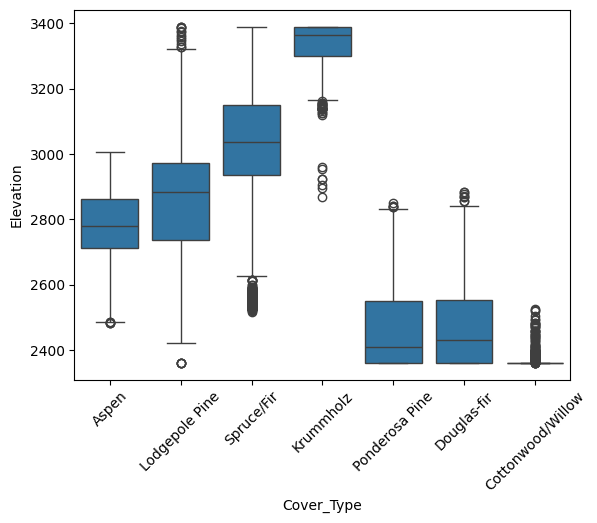

In [ ]:
x= 'Cover_Type'
y = 'Elevation'
boxplot(x,y)

Its clearly observed each forest cartegories having the differnet medain values of elevation. So can use this feature for classification.

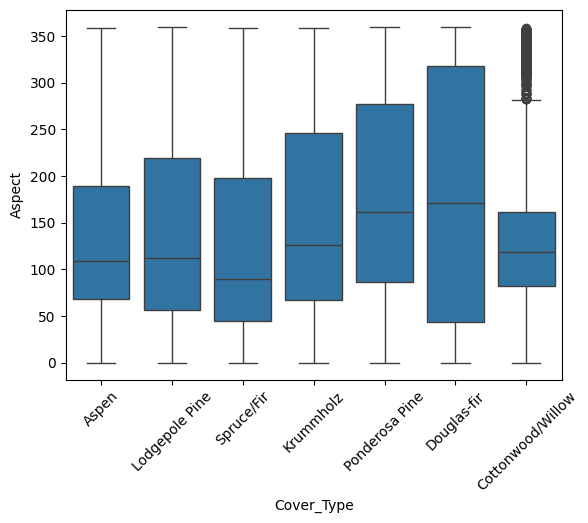

In [ ]:
#2. Aspect Vs Cover_Type
x = "Cover_Type"
y = "Aspect"
boxplot(x,y)

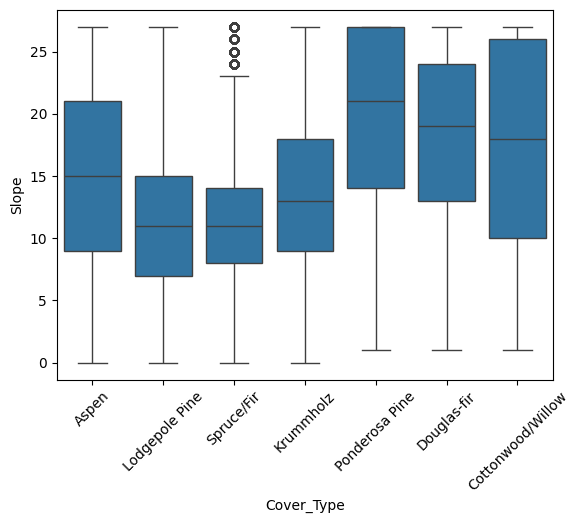

In [ ]:
#3. slope Vs Cover_Type
x = "Cover_Type"
y = "Slope"
boxplot(x,y)

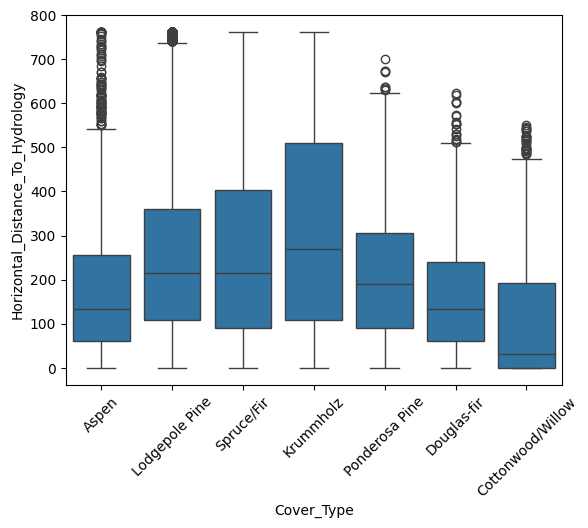

In [ ]:
#4. Horizontal_Distance_To_Hydrology Vs Cover_Type
x = "Cover_Type"
y = "Horizontal_Distance_To_Hydrology"
boxplot(x,y)

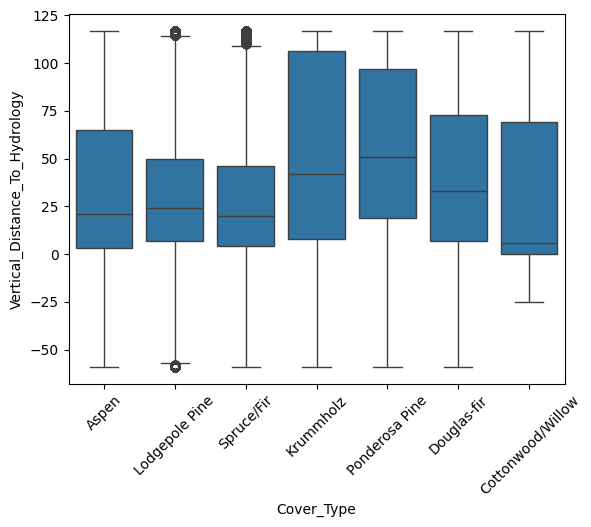

In [ ]:
#4. Vertical_Distance_To_Hydrology Vs Cover_Type
x = "Cover_Type"
y = "Vertical_Distance_To_Hydrology"
boxplot(x,y)

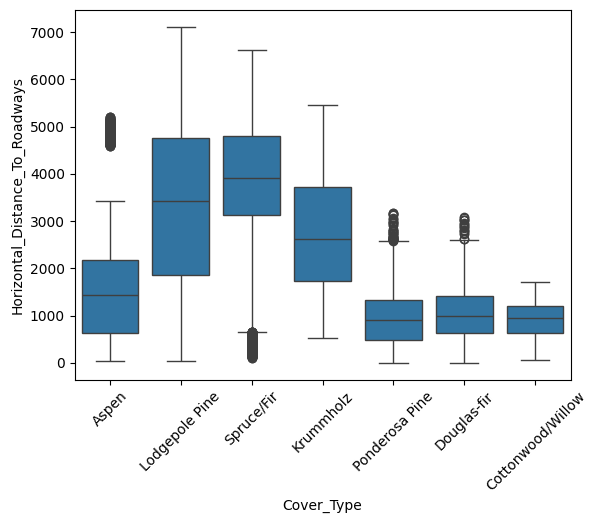

In [ ]:

#5. Horizontal_Distance_To_Roadways Vs Cover_Type
x = "Cover_Type"
y = "Horizontal_Distance_To_Roadways"
boxplot(x,y)

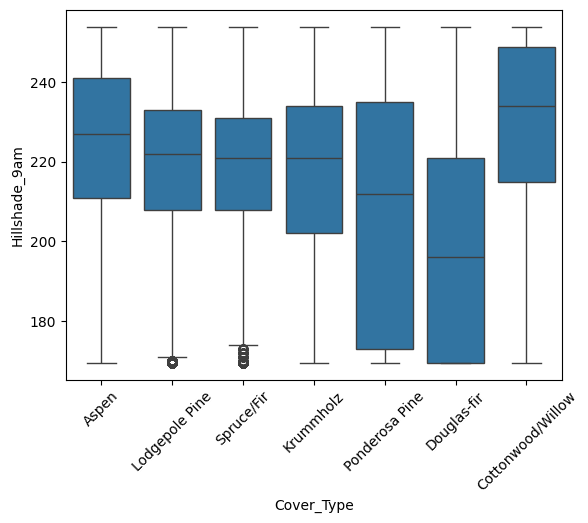

In [ ]:
#6. Hillshade_9am Vs Cover_Type
x = "Cover_Type"
y = "Hillshade_9am"
boxplot(x,y)

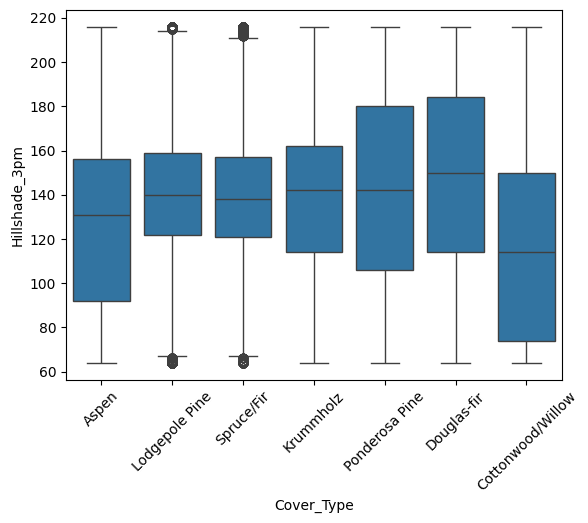

In [ ]:
#7. Hillshade_3pm Vs Cover_Type
x = "Cover_Type"
y = "Hillshade_3pm"
boxplot(x,y)

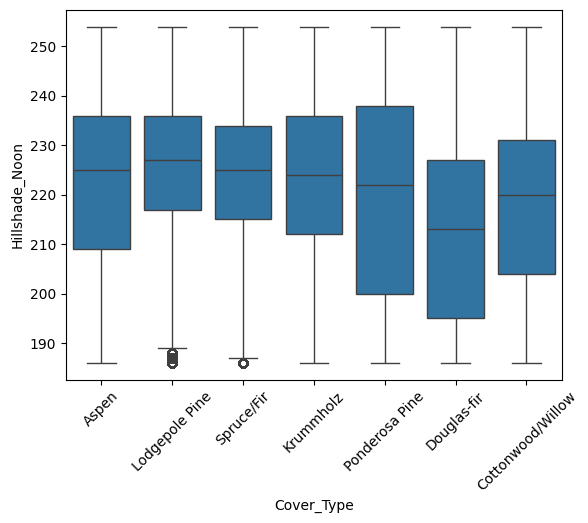

In [ ]:
#8. Hillshade_Noon Vs Cover_Type
x = "Cover_Type"
y = "Hillshade_Noon"
boxplot(x,y)

In [ ]:
#9.Horizontal_Distance_To_Fire_Points Vs